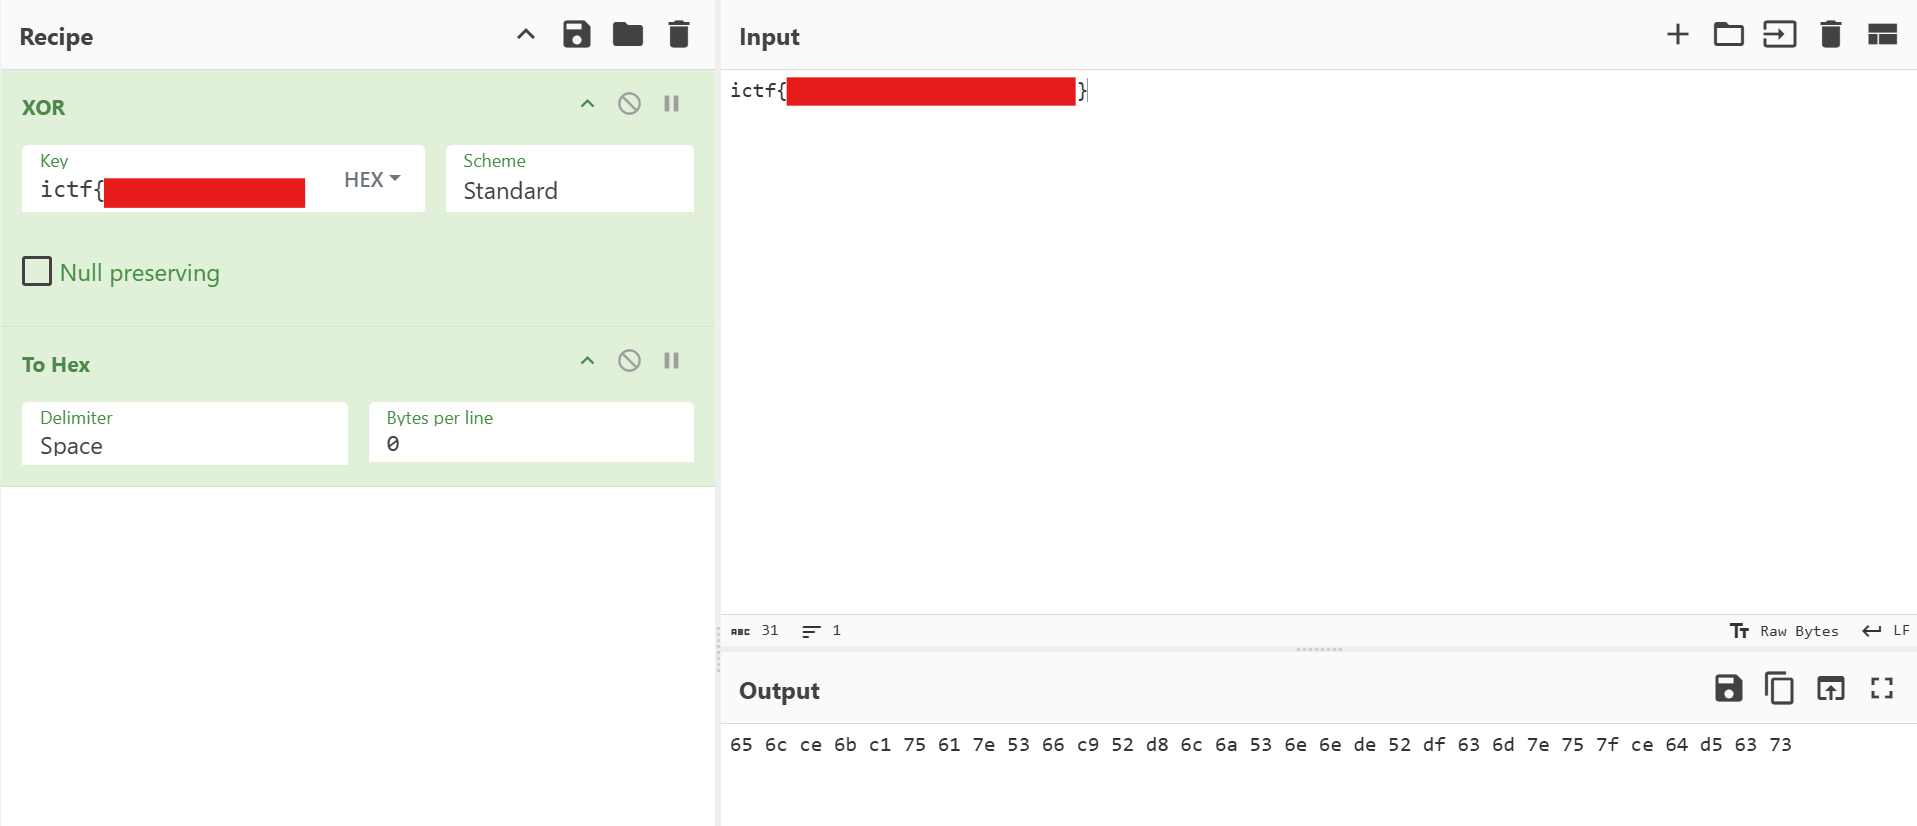

The problem is that hex mode on cyberchef removes all non hex chars:

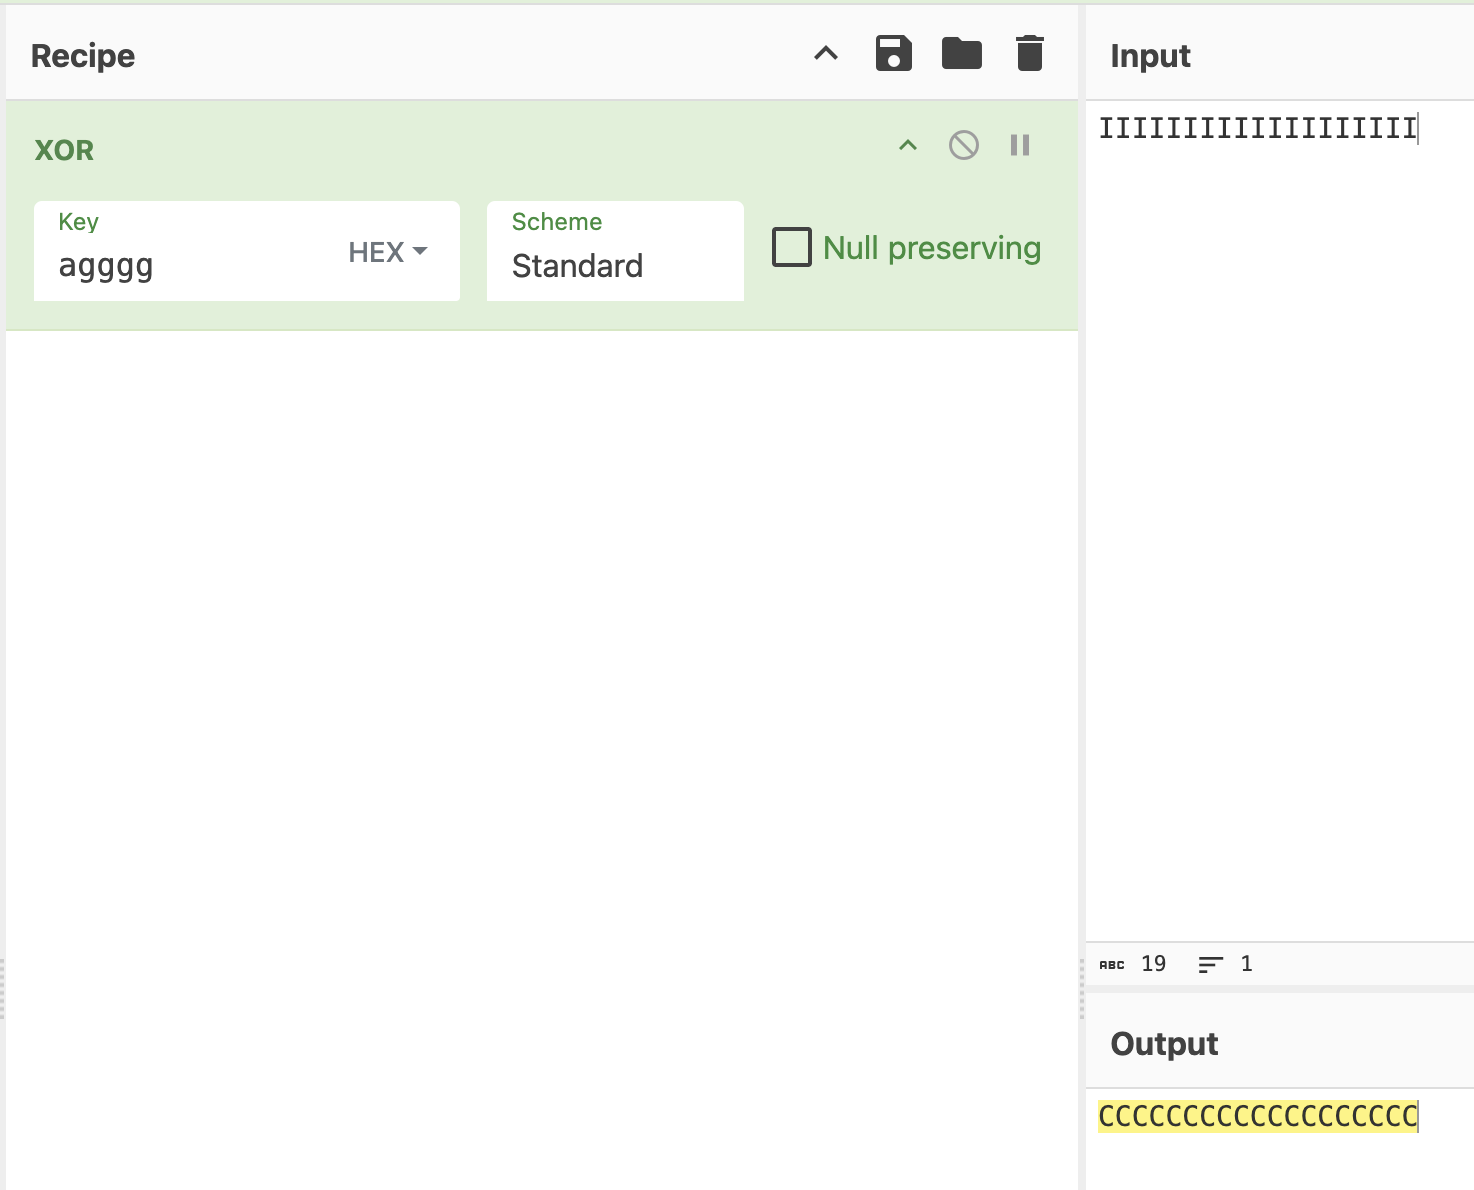

That means that the key is now rotating and must start with an "c", so `\x0c` and then and "f" for `\x0f`

In [73]:
output = bytes.fromhex("""65 6c ce 6b c1 75 61 7e 53
66
c9 52 d8 6c
6a
53 6e 6e de
52 df 63 6d 7e 75 7f ce 64 d5 63 73
""".replace("\n","").replace(" ",""))

In [74]:
output

b'el\xcek\xc1ua~Sf\xc9R\xd8ljSnn\xdeR\xdfcm~u\x7f\xced\xd5cs'

In [75]:
xor = lambda x,y:bytes(a^b for a,b in zip(x,y))

key = xor(output[:5],b"ictf{")
key

b'\x0c\x0f\xba\r\xba'

In [31]:
for spacer in range(10):
    fullkey = (key + (b"\x00" * spacer)) * 10
    plaintext = xor(output,fullkey)
    print(spacer,plaintext)

0 b'ictf{yn\xc4^\xdc\xc5]ba\xd0_a\xd4\xd3\xe8\xd3l\xd7s\xcfs\xc1\xde\xd8\xd9\x7f'
1 b'ictf{umq\xe9ksR\xd4c\xd0^\xd4n\xd2]en\xd7~yptioc\x7f'
2 b'ictf{uar\\\xdc\xc4\xe8\xd8lf\\\xd4cdR\xdfob\xc4x\xc5\xced\xd9l\xc9'
3 b'ictf{ua~_is_bljSbad_ecm~yptiocs'
4 b'ictf{ua~Sj\xc6\xe8\xd5\xd6jSnn\xd2]en\xd7~u\x7f\xceh\xda\xd9~'
5 b'ictf{ua~Sf\xc5]ba\xd0Snn\xdeR\xd3l\xd7s\xcf\x7f\xced\xd5c\x7f'
6 b'ictf{ua~Sf\xc9^\xd7\xd6g\xe9nn\xdeR\xdfcaq\xcfrtd\xd5cs'
7 b'ictf{ua~Sf\xc9R\xd4c\xd0^\xd4n\xdeR\xdfcm~yptiocs'
8 b'ictf{ua~Sf\xc9R\xd8`e\xe9c\xd4\xdeR\xdfcm~u\x7f\xc2kon\xc9'
9 b'ictf{ua~Sf\xc9R\xd8lf\\\xd4cdR\xdfcm~u\x7f\xced\xd9l\xc9'


So, `3 b'ictf{ua~_is_bljSbad_ecm~yptiocs'` looks already like a good hit, but now we also deducted how long. The known key is $5$ bytes long, and the spacer in that interation (lets call it fillter) is $3$ bytes $\implies$ They key is $8$ bytes long.

1. However, we also know that it needs to end on a "}"
2. Then, we just need to bruteforce the over two bytes until we are happy

In [56]:
bytes([output[-1]])

b's'

In [ ]:
len(output) % 8 # so we actually know only the seven'th byte

7

In [59]:
finalkey = key + b"\x00" + xor(bytes([output[-1]]),b"}") + b"\x00"
finalkey

b'\x0c\x0f\xba\r\xba\x00\x0e\x00'

In [76]:
xor(output,finalkey * 5)

b'ictf{uo~_is_bldSbad_ecc~yptioc}'

In [118]:
results = []
for a in range(256):
    for b in range(256):
        triedkey = key + bytes([a]) + xor(bytes([output[-1]]),b"}") + bytes([b])
        results.append(
            xor(output,triedkey * 5)
        )

In [122]:
import random
def dec(x):
    try:
        x.decode("ascii")
        return True
    except:
        return False

selected = [result for result in results if dec(result) and result.decode("ascii").isprintable()]
random.shuffle(selected)
selected[:10]

[b'ictf{;oq_is_b"d\\bad_e-cqyptio-}',
 b'ictf{3oo_is_b*dBbad_e%coyptio%}',
 b'ictf{lo[_is_budvbad_ezc[yptioz}',
 b'ictf{no`_is_bwdMbad_exc`yptiox}',
 b'ictf{MoC_is_bTdnbad_e[cCyptio[}',
 b'ictf{YoH_is_b@debad_eOcHyptioO}',
 b'ictf{`od_is_bydIbad_evcdyptiov}',
 b'ictf{joT_is_bsdybad_e|cTyptio|}',
 b'ictf{YoT_is_b@dybad_eOcTyptioO}',
 b'ictf{JoV_is_bSd{bad_e\\cVyptio\\}']

In [123]:
for res in results:
    if b"encryption" in res: print(res)

b'ictf{xor_is_bad_bad_encryption}'
